# Aula 6: Séries Temporais - Fundamentos

## Teoria

### Conceitos
- Estacionariedade, autocorrelação, componentes (tendência, sazonalidade, ruído).
- Diferença entre séries temporais e dados tabulares.

### Modelos ARIMA
- AR (AutoRegressive), I (Integrated), MA (Moving Average).
- Equação: $X_t = c + \phi_1 X_{t-1} + ... + \phi_p X_{t-p} + \epsilon_t + \theta_1 \epsilon_{t-1} + ... + \theta_q \epsilon_{t-q}$.

## Objetivo Prático
- Implementar ARIMA no dataset de vendas.

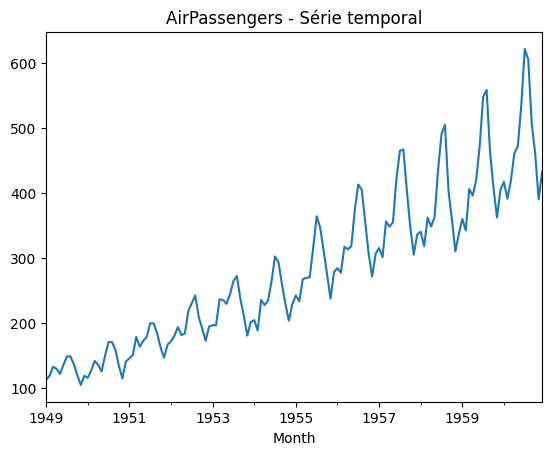

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o dataset
df = pd.read_csv("AirPassengers.csv")

# Ajustar índice de tempo
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

series = df['#Passengers']  # coluna original
series.plot(title="AirPassengers - Série temporal")
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.api import VAR, VARMAX

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


                            AutoReg Model Results                             
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                    AutoReg(12)   Log Likelihood                -530.959
Method:               Conditional MLE   S.D. of innovations             13.511
Date:                Thu, 11 Sep 2025   AIC                           1089.918
Time:                        23:54:16   BIC                           1130.277
Sample:                    01-01-1950   HQIC                          1106.318
                         - 12-01-1960                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.4369      3.450      2.735      0.006       2.675      16.198
#Passengers.L1      0.4437      0.074      6.017      0.000       0.299       0.588
#Passengers.L2     -0.2716      

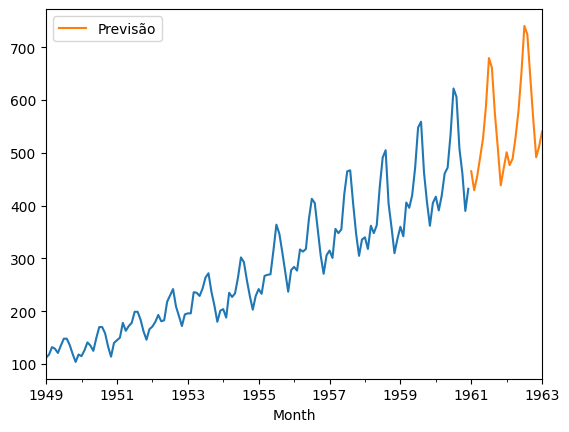

In [ ]:
# AR
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(series, lags=12).fit()
print(model.summary())

pred = model.predict(start=len(series), end=len(series)+24)
series.plot(label="Original")
pred.plot(label="Previsão", legend=True)
plt.show()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Thu, 11 Sep 2025   AIC                           1353.347
Time:                        23:52:25   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.124    -14.814      0.0

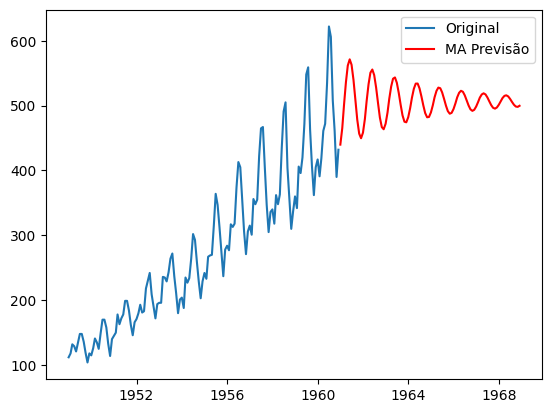

In [ ]:
# MA
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(series, order=(2,1,2)).fit()
print(model.summary())

pred = model.forecast(steps=96)
plt.plot(series, label="Original")
plt.plot(pred, label="MA Previsão", color="red")
plt.legend()
plt.show()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(4, 1, 4)   Log Likelihood                -662.195
Date:                Thu, 11 Sep 2025   AIC                           1342.390
Time:                        23:53:17   BIC                           1369.055
Sample:                    01-01-1949   HQIC                          1353.225
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0349      0.063     -0.559      0.576      -0.157       0.088
ar.L2          1.0235      0.056     18.177      0.000       0.913       1.134
ar.L3         -0.0675      0.044     -1.519      0.1

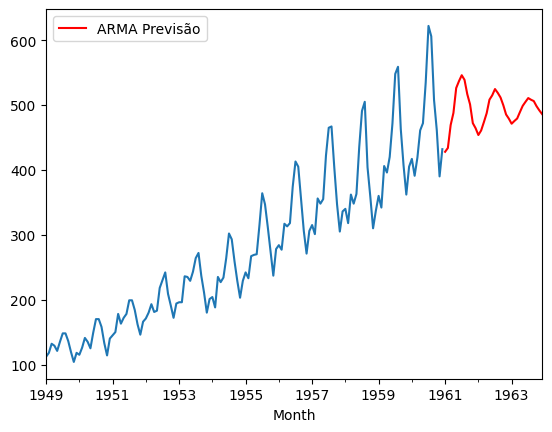

In [ ]:
# ARMA
model = ARIMA(series, order=(4,1,4)).fit()
print(model.summary())

pred = model.forecast(steps=36)
series.plot(label="Original")
pred.plot(label="ARMA Previsão", color="red", legend=True)
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Thu, 11 Sep 2025   AIC                           1353.347
Time:                        12:31:33   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.059      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.419      0.000      -0.989      -0.921
ma.L1         -1.8432      0.125    -14.790      0.0

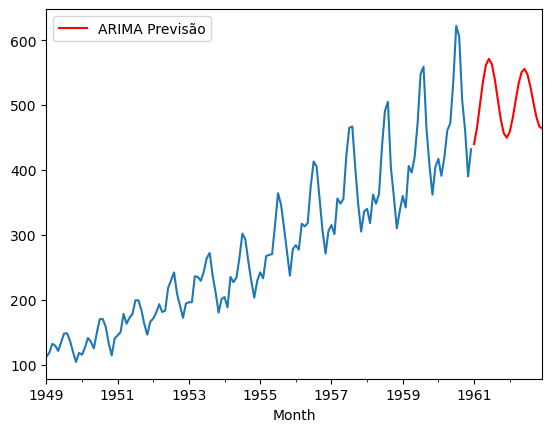

In [ ]:
# ARIMA
model = ARIMA(series, order=(2,1,2)).fit()
print(model.summary())

pred = model.forecast(steps=24)
series.plot(label="Original")
pred.plot(label="ARIMA Previsão", color="red", legend=True)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Thu, 11 Sep 2025   AIC                           1022.299
Time:                                    23:54:45   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

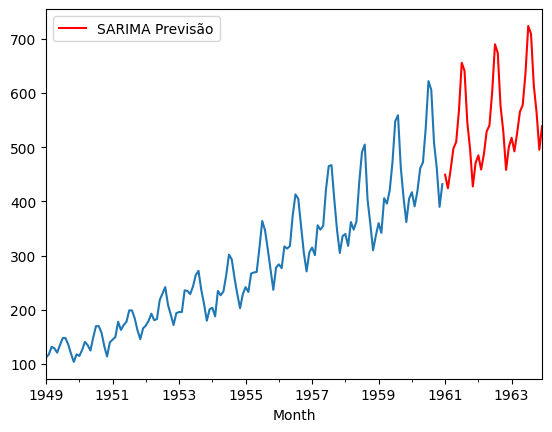

In [ ]:
# SARIMA
import statsmodels.api as sm

sarima = sm.tsa.statespace.SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
print(sarima.summary())

pred = sarima.forecast(steps=36)
series.plot(label="Original")
pred.plot(label="SARIMA Previsão", color="red", legend=True)
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.106
Date:                            Thu, 11 Sep 2025   AIC                           1024.212
Time:                                    23:57:18   BIC                           1041.464
Sample:                                01-01-1949   HQIC                          1031.222
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1831      0.530      0.345      0.730      -0.856       1.222
ar.L1         -0.1320      0.359   

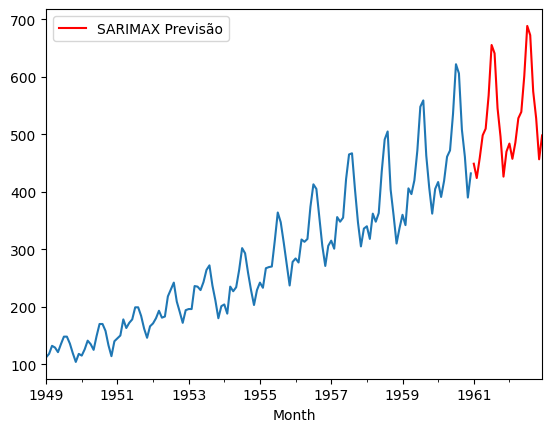

In [ ]:
# SARIMAX
# Exógeno (exemplo sintético: série de temperatura)
'''
Aqui precisaríamos de uma variável externa (ex: preço de combustível, PIB, etc.).
Como não temos no dataset, podemos simular:
'''
import numpy as np

exog = np.random.normal(size=len(series))  # variável exógena fictícia

sarimax = sm.tsa.statespace.SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12), exog=exog).fit()
print(sarimax.summary())

future_exog = np.random.normal(size=24)
pred = sarimax.forecast(steps=24, exog=future_exog)

series.plot(label="Original")
pred.plot(label="SARIMAX Previsão", color="red", legend=True)
plt.show()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 11, Sep, 2025
Time:                     23:59:32
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    11.7840
Nobs:                     142.000    HQIC:                   11.6604
Log likelihood:          -1214.86    FPE:                    106495.
AIC:                      11.5758    Det(Omega_mle):         99373.5
--------------------------------------------------------------------
Results for equation passengers
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                15.325960         6.880275            2.228           0.026
L1.passengers         1.324201         0.085435           15.499           0.000
L1.shifted           -0.320146         0.261685        

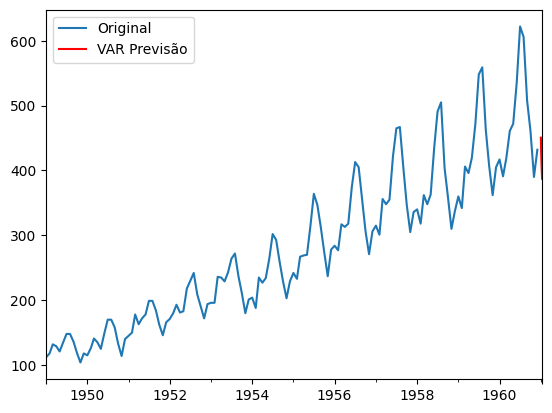

In [ ]:
# VAR
# Criar série multivariada
import numpy as np
from statsmodels.tsa.api import VAR

df_multi = pd.DataFrame({
    "passengers": series,
    "shifted": series.shift(1).fillna(0) + np.random.normal(scale=10, size=len(series))
})

model = VAR(df_multi)
fit = model.fit(2)
print(fit.summary())

pred = fit.forecast(df_multi.values[-2:], steps=12)
pred_df = pd.DataFrame(pred, index=pd.date_range(series.index[-1]+pd.offsets.MonthBegin(), periods=12), columns=df_multi.columns)

df_multi["passengers"].plot(label="Original")
pred_df["passengers"].plot(label="VAR Previsão", color="red")
plt.legend()
plt.show()



In [ ]:
# VARMA
model = sm.tsa.VARMAX(df, order=(2,2)).fit(disp=False)
print(model.summary())

pred = model.forecast(steps=10)
df["y1"].plot(label="Original y1")
pred["y1"].plot(label="Previsão y1", color="red")
plt.legend()
plt.show()


In [ ]:
# VArmax
exog2 = np.random.normal(size=(1))

model = VARMAX(df, order=(1,1), exog=exog2).fit(disp=False)
print(model.summary())

future_exog = np.random.normal(size=(5,1))
pred = model.forecast(steps=5, exog=future_exog)

df["y1"].plot(label="Original y1")
pred["y1"].plot(label="Previsão y1", color="red")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


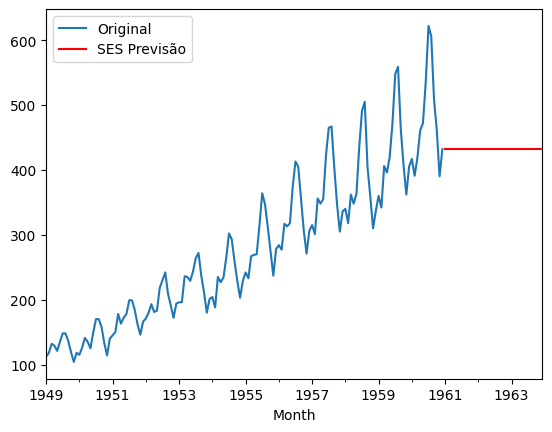

In [ ]:
# SES Simple Exponential Smoothing
# model = SimpleExpSmoothing(series).fit()
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

model = SimpleExpSmoothing(series).fit()
pred = model.forecast(36)

series.plot(label="Original")
pred.plot(label="SES Previsão", color="red")
plt.legend()
plt.show()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


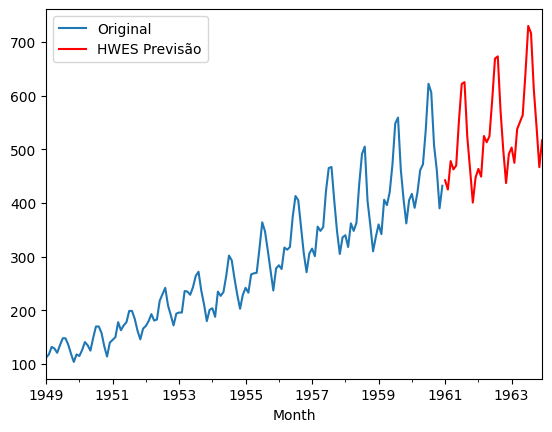

In [ ]:
# Holt Winters Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(series, trend="add", seasonal="mul", seasonal_periods=36).fit()
pred = model.forecast(36)

series.plot(label="Original")
pred.plot(label="HWES Previsão", color="red")
plt.legend()
plt.show()

In [ ]:
# LSTM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Carregar dataset
df = pd.read_csv("AirPassengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

series = df['#Passengers'].values.reshape(-1,1)

# Normalização (melhora treino da rede)
scaler = MinMaxScaler(feature_range=(0,1))
series_scaled = scaler.fit_transform(series)


In [ ]:
def create_dataset(data, time_steps=12):
    X, y = [], []
    for i in range(len(data)-time_steps):
        X.append(data[i:(i+time_steps), 0])
        y.append(data[i+time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 24  # usar 12 meses anteriores para prever o próximo
X, y = create_dataset(series_scaled, time_steps)

# Ajustar forma [amostras, time_steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Divisão treino/teste
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [ ]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_steps, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=1000, batch_size=16, validation_data=(X_test, y_test), verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.1083 - val_loss: 0.2709
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0616 - val_loss: 0.1319
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0293 - val_loss: 0.0315
Epoch 4/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0113 - val_loss: 0.0223
Epoch 5/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0122 - val_loss: 0.0212
Epoch 6/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0080 - val_loss: 0.0308
Epoch 7/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0094 - val_loss: 0.0305
Epoch 8/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0072 - val_loss: 0.0240
Epoch 9/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0068 - val_loss: 0.0206
Epoch 10/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0072 - val_loss: 0.0202
Epoch 11/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0057 - val_loss: 0.0207
Epoch 12/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


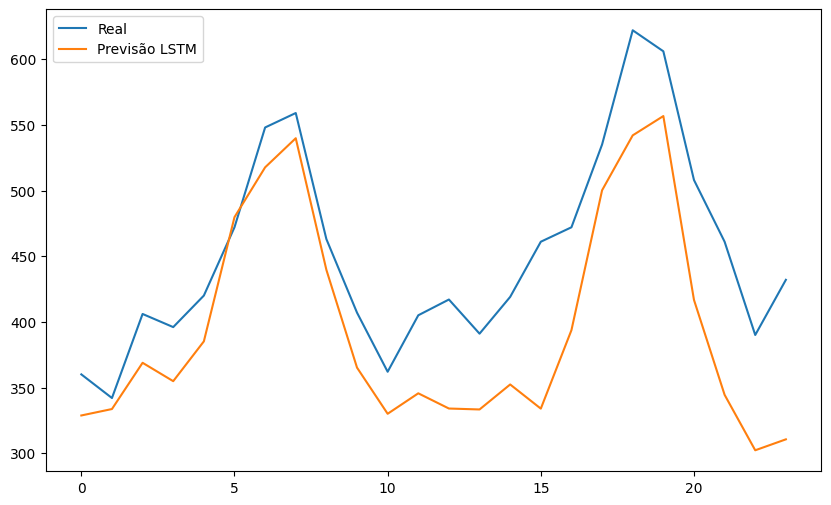

In [ ]:
y_pred = model.predict(X_test)

# Reverter normalização
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_inv = scaler.inverse_transform(y_pred)

# Plotar resultados
plt.figure(figsize=(10,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Previsão LSTM")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


C:\Users\Leandro Silva\AppData\Local\Temp\ipykernel_30304\3107080626.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1]+pd.offsets.MonthBegin(), periods=24, freq='M'), future_inv, label="Previsão futura (LSTM)", color="red")


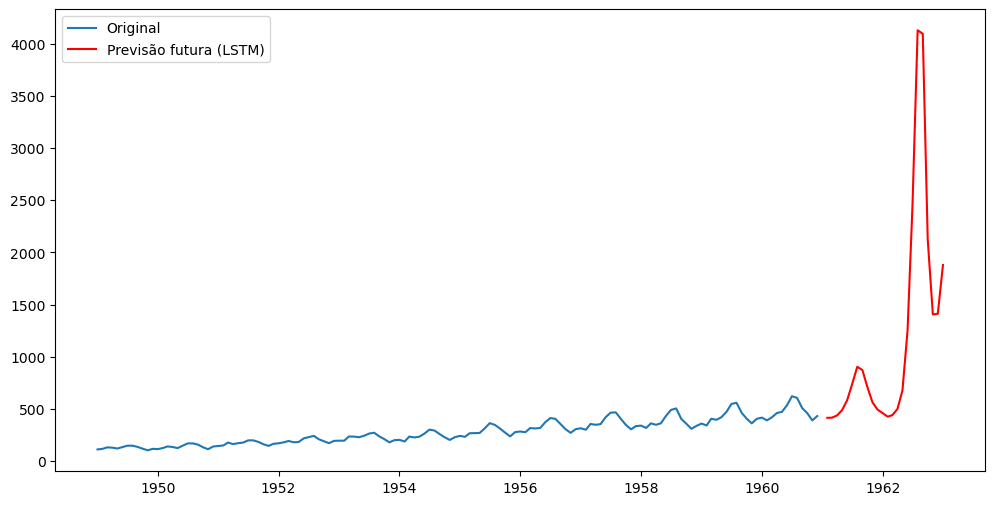

In [ ]:
# previsão 24 meses
last_sequence = series_scaled[-time_steps:]
future = []

current_seq = last_sequence.reshape(1, time_steps, 1)

for _ in range(24):  # prever 24 meses à frente
    pred = model.predict(current_seq)[0][0]
    future.append(pred)
    # Atualizar sequência (deslizar janela)
    current_seq = np.append(current_seq[:,1:,:], [[[pred]]], axis=1)

future_inv = scaler.inverse_transform(np.array(future).reshape(-1,1))

# Plotar série + previsão
plt.figure(figsize=(12,6))
plt.plot(df.index, series, label="Original")
plt.plot(pd.date_range(df.index[-1]+pd.offsets.MonthBegin(), periods=24, freq='M'), future_inv, label="Previsão futura (LSTM)", color="red")
plt.legend()
plt.show()


# **Exercício**

Carregue o dataset train.csv, agrupe os valores de venda por mes/ano e aplique as técnicas que desenvolvemos acima e analise qual trouxe melhor resultado a este conjunto de dados.